# TADKit - Interactive Anomaly Detection demonstrator
## <font color="purple"> Loading use case </font>
<font color="orange"> Where you import your data. We simply generate some synthetic timeseries. We either use the synchronous format where each timeseries is a column with label as a column name, or the asynchronous format with the two columns ("sensor", "data") where "sensor" has the timeseries labels and "data" their corresponding values. </font>

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19
2021-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-01-01 01:00:00,0.005252,0.024728,0.026952,-0.022360,-0.029462,0.028039,-0.007014,0.012071,-0.024431,0.027290,-0.008894,-0.029470,-0.015765,0.024170,0.006056,-0.019567,0.052675,0.054966,0.037385,0.035398
2021-01-01 02:00:00,0.027888,-0.032840,0.062813,-0.024298,-0.024962,0.007937,-0.027353,0.033791,-0.059576,0.030615,-0.041340,-0.041302,0.028096,0.013593,-0.032369,-0.030601,0.055585,0.082502,0.046551,0.018346
2021-01-01 03:00:00,-0.006903,-0.060266,0.034705,-0.011602,-0.023157,-0.018953,0.003918,0.043048,-0.005327,0.018585,-0.049878,-0.077205,0.015227,-0.014894,-0.046688,-0.023597,0.076257,0.045855,0.041023,-0.013725
2021-01-01 04:00:00,0.041263,-0.051675,-0.021960,0.007861,0.001067,-0.053171,0.041826,-0.002919,0.031187,0.003237,-0.069468,-0.150257,-0.005190,-0.035196,-0.033748,-0.084091,0.091617,0.078086,0.077962,-0.021141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-02-11 11:00:00,-0.045880,-0.710766,-0.097687,1.036003,0.674646,0.726933,0.529645,0.031269,0.890464,-0.861574,-0.490439,-0.239189,-0.129772,-0.522085,0.307080,0.145893,0.437884,-0.842048,0.190714,0.357574
2021-02-11 12:00:00,-0.042093,-0.749522,-0.106187,1.042480,0.636715,0.668605,0.487211,0.003060,0.909014,-0.847666,-0.548754,-0.219306,-0.158270,-0.566806,0.305682,0.200074,0.402115,-0.870675,0.148192,0.400314
2021-02-11 13:00:00,-0.039539,-0.816215,-0.103101,1.023325,0.670355,0.665394,0.430242,0.038435,0.844820,-0.885687,-0.529422,-0.166633,-0.132188,-0.563205,0.275267,0.167789,0.399349,-0.837403,0.114430,0.363303
2021-02-11 14:00:00,0.045796,-0.803112,-0.105205,1.049967,0.643303,0.664459,0.465075,0.069509,0.930086,-0.889746,-0.534425,-0.147937,-0.141524,-0.562967,0.289132,0.150164,0.399101,-0.806114,0.096359,0.326373


,sensor,data
2021-01-01 00:00:00,X0,0.000000
2021-01-01 01:00:00,X0,0.005252
2021-01-01 02:00:00,X0,0.027888
2021-01-01 03:00:00,X0,-0.006903
2021-01-01 04:00:00,X0,0.041263
...,...,...
2021-02-11 11:00:00,X19,0.357574
2021-02-11 12:00:00,X19,0.400314
2021-02-11 13:00:00,X19,0.363303
2021-02-11 14:00:00,X19,0.326373


<Axes: >

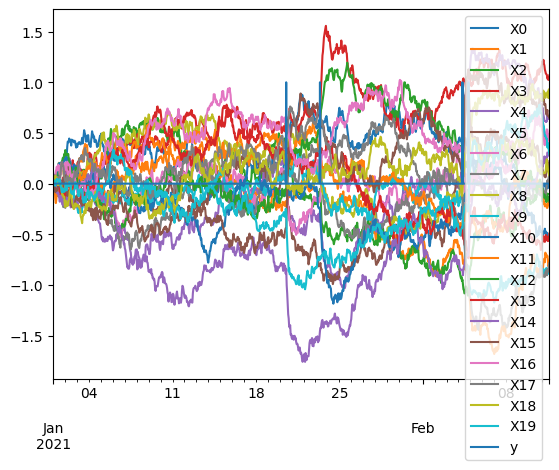

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ouagen import ornstein_uhlenbeck_anomaly


t = np.arange(1000)
t = t / t.shape[0]
pre_X, pre_y = ornstein_uhlenbeck_anomaly(
    t,
    size=20,
    noise_scale=1,
    mean_reverting=3,
    anomaly_freq=.1,
    anomaly_duration=0.005,
    anomaly_scale=40,
)
t = pd.to_datetime('2021-01-01') + pd.Timedelta(1, 'h') * np.arange(t.shape[0])
X = pd.DataFrame(pre_X, index=t, columns=[f'X{i}' for i in range(pre_X.shape[1])])
y = pd.DataFrame(pre_y[:, None], index=t, columns=['y'])
display(X)
async_X = X.melt(value_vars=X.columns.tolist(), ignore_index=False).rename(
    columns={"variable": "sensor", "value": "data"}
)
display(async_X)
pd.concat([X, y], axis=1).plot()

In [2]:
async_X.index.name = "timestamp"

## <font color="purple"> `Formalizer`: given a use case, define how to _formalize_ the dataset for ML </font>
<font color="orange"> Select a Formalizer: tadkit-provided object adapted to the use case type (synchronous or asynchronous) you are set on learning. </font>

In [3]:
from tadkit.catalog.arrayformalizer import ArrayToPandasFormalizer

formalizers = {
    "synchronous_formalizer": ArrayToPandasFormalizer(
        data=X,
        dataframe_type="synchronous",
    ),
    "asynchronous_formalizer": ArrayToPandasFormalizer(
        data=async_X,
        dataframe_type="asynchronous",
    )
}
for formalizer_name, formalizer in formalizers.items():
    print(f"{formalizer_name} has {formalizer.available_properties=}")

synchronous_formalizer has formalizer.available_properties=['fixed_time_step', 'synchronous']
asynchronous_formalizer has formalizer.available_properties=['fixed_time_step', 'asynchronous']


In [4]:
import ipywidgets as widgets

# Create a dropdown selection widget
formalizer_widget = widgets.Dropdown(
    options=list(formalizers.keys()),
    value='synchronous_formalizer',
    description='Select:'
)
display(formalizer_widget)

Dropdown(description='Select:', options=('synchronous_formalizer', 'asynchronous_formalizer'), value='synchron…

<font color="orange"> This allows to select a training interval, a resampling resolution and the set of target sensors for learning. </font>

In [5]:
from query_selection import query_widget_selection

formalizer = formalizers[formalizer_widget.value]
query_dict = query_widget_selection(formalizer.query_description)

In [6]:
formalizer.available_properties

['fixed_time_step', 'synchronous']

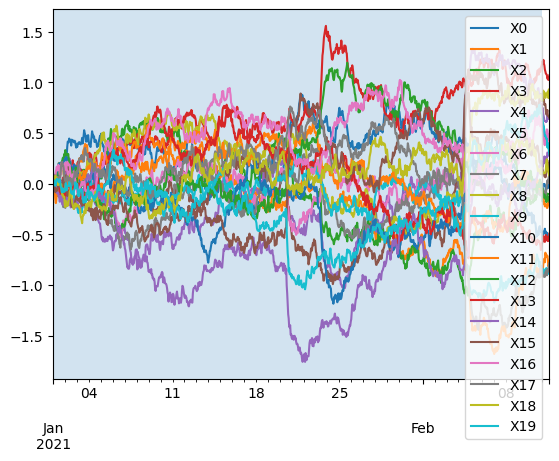

In [7]:
query_translated = {key: widget.value for key, widget in query_dict.items()}
X_train = formalizer.formalize(**query_translated)
query_translated.pop("target_period")
X_test = formalizer.formalize(**query_translated)

ax = X_test.plot()
ax.axvspan(X_train.index[0], X_train.index[-1], alpha=0.2)
plt.show()

<font color="orange"> The dataset formalizing is done and ready for learning.

## <font color="purple"> `TADLearner`: detect anomalies </font>

In [8]:
from tadkit.catalog.learners import installed_learner_classes
installed_learner_classes

[TADKit-Catalog]
Class learner_name='cnndrad' is registered in TADKit.
cnndrad returns err=ModuleNotFoundError("No module named 'cnndrad'").
Class learner_name='sbad' is registered in TADKit.
sbad returns err=ModuleNotFoundError("No module named 'sbad_fnn'").
Class learner_name='kcpd' is registered in TADKit.
kcpd returns err=ModuleNotFoundError("No module named 'kcpdi'").
Class learner_name='tdaad' is registered in TADKit.
tdaad is operational in this environment.
tdaad is implicit child of TADLearner.
Class learner_name='isolation-forest' is registered in TADKit.
isolation-forest is operational in this environment.
isolation-forest is implicit child of TADLearner.
Class learner_name='kernel-density' is registered in TADKit.
kernel-density is operational in this environment.
kernel-density is implicit child of TADLearner.


{'tdaad': tdaad.anomaly_detectors.TopologicalAnomalyDetector,
 'isolation-forest': sklearn.ensemble._iforest.IsolationForest,
 'kernel-density': sklearn.neighbors._kde.KernelDensity}

<font color="orange"> Select a set of learners that are compatible with the formalizing. </font>

In [9]:
from tadkit.utils.match_formalizer_learners import match_formalizer_learners

matching_available_learners = match_formalizer_learners(formalizer, installed_learner_classes)
matching_available_learners

{'tdaad': tdaad.anomaly_detectors.TopologicalAnomalyDetector,
 'isolation-forest': sklearn.ensemble._iforest.IsolationForest,
 'kernel-density': sklearn.neighbors._kde.KernelDensity}

<font color="orange"> Finally, set the parameters of the chosen learners. </font>

In [10]:
from tadkit.utils.widgets_from_metadata import render_widgets_from_metadata

learner_params = {}
for learner_name, learner_class in matching_available_learners.items():
    learner_params.setdefault(learner_name, {})
    print(learner_name)
    learner_params[learner_name] = render_widgets_from_metadata(learner_class.metadata)

tdaad


isolation-forest


kernel-density


In [11]:
learners = {
    learner_class_name:
    installed_learner_classes.get(learner_class_name)(
        **{param: selection.value for (param, selection) in params_dict.items()}
    )
    for learner_class_name, params_dict in learner_params.items()
}
learners

{'tdaad': TopologicalAnomalyDetector(),
 'isolation-forest': IsolationForest(random_state=0),
 'kernel-density': KernelDensity(bandwidth='scott')}

<font color="orange"> Fit on train query, score on the entire series. </font>

In [ ]:
# Fit loop:
anomalies = pd.DataFrame(index=X_test.index)
for learner_name, learner_object in learners.items():
    print(f"Fitting {learner_name}")
    learner_object.fit(X_train)

# Score loop:
for learner_name, fitted_learner_object in learners.items():
    print(f"Scoring with {learner_name}")
    anom_score = fitted_learner_object.score_samples(X_test)
    anomalies[str(fitted_learner_object)] = anom_score

axes = pd.concat([anomalies, y], axis=1).plot(subplots=True)
[ax.axvspan(X_train.index[0], X_train.index[-1], alpha=0.2) for ax in axes]
plt.show()

Fitting tdaad


In [ ]:
from plotly.offline import init_notebook_mode, iplot
from plotly.graph_objs import *
init_notebook_mode(connected=True)         # initiate notebook for offline plot

pd.options.plotting.backend = "plotly"
fig = pd.concat([anomalies.apply(lambda x: (x - x.min()) / (x.max() - x.min())), y], axis=1).plot()
fig.update_layout(
    legend=dict(
        orientation="v",
        entrywidth=100,
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    width=1000,
    height=600,
)
fig.show()
pd.options.plotting.backend = "matplotlib"